In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('coaster_db.csv')

Data preperation

In [6]:
df.columns #inspect columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='str')

In [10]:
# remove unwanted columns(by doing a subseted data frame)(using copy() is to indicate that it is a new dataframe not just a reference to the old one !)

df = df[['coaster_name',
    #'Length', 'Speed', 
     'Location', 'Status',
    # 'Opening date',
    #'Type',
       'Manufacturer',
    #   'Height restriction', 'Model', 'Height',
    #   'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
    #   'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
    #   'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
    #   'Track layout', 'Fastrack available', 'Soft opening date.1',
    #   'Closing date','Opened',
    # 'Replaced by', 'Website',
    #   'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
    #   'Single rider line available', 'Restraint Style',
    #   'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean',
       #'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph',
       #'height_value', 'height_unit',
       'height_ft',
       'Inversions_clean', 'Gforce_clean']].copy()

In [16]:
df.shape # we find that it now has 13 columns

df.dtypes # we check the types to see if something needs fixing 

df['opening_date_clean'] = pd.to_datetime(df['opening_date_clean']) # converted from a str to date time 

In [20]:
#Rename columns
df.columns # there are some inconsistances with naming  so we got to fix them 
#Renameing is done using dictionary data type
df = df.rename(columns = {'coaster_name' : 'Coaster_Name' ,
                   'year_introduced' : 'Year_Introduced' ,
                   'opening_date_clean' : 'Opening_Date',
                   'speed_mph' : 'Speed_mph',
                   'height_ft' : 'Height_ft',
                   'Inversions_clean' : 'Inversions',
                   'Gforce_clean' : 'Gforce'})

In [29]:
print (df.isna().sum(), "\n") # check if we have missing values

Coaster_Name         0
Location             0
Status             213
Manufacturer        59
Year_Introduced      0
latitude           275
longitude          275
Type_Main            0
Opening_Date       250
Speed_mph          150
Height_ft          916
Inversions           0
Gforce             725
dtype: int64 



In [30]:
df.duplicated() # check if we have duplicates

df.loc[df.duplicated()] # "loc" to 'see' which ones(full row) are duplicated (in this case we dont have any)


,Coaster_Name,Location,Status,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date,Speed_mph,Height_ft,Inversions,Gforce


In [32]:
df.loc[df.duplicated(subset= ['Coaster_Name'])] # check if we have duplicates in specific columns(this shows the rows 'the seconed time they occur')

,Coaster_Name,Location,Status,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date,Speed_mph,Height_ft,Inversions,Gforce
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
60,Derby Racer,Revere Beach,Removed,Fred W. Pearce,1937,42.4200,-70.9860,Wood,1911-01-01,NaN,NaN,0,NaN
61,Blue Streak (Conneaut Lake),Conneaut Lake Park,Closed,NaN,1938,41.6349,-80.3180,Wood,1938-05-23,50.0,NaN,0,NaN
167,Big Thunder Mountain Railroad,Other,NaN,Arrow Development (California and Florida)Dyna...,1980,NaN,NaN,Steel,NaT,35.0,NaN,0,NaN
237,Thunder Run (Canada's Wonderland),Canada's Wonderland,Operating,Mack Rides,1986,43.8427,-79.5423,Steel,1981-05-23,39.8,32.8,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,Lil' Devil Coaster,Six Flags Great Adventure,Operating,Zamperla,2021,40.1343,-74.4434,Steel,1999-01-01,NaN,NaN,0,NaN
1064,Little Dipper (Conneaut Lake Park),Conneaut Lake Park,Operating,Allan Herschell Company,2021,41.6343,-80.3165,Steel,1950-01-01,NaN,NaN,0,NaN
1080,Iron Gwazi,Busch Gardens Tampa Bay,Under construction,Rocky Mountain Construction,2022,28.0339,-82.4231,Steel,NaT,76.0,NaN,2,NaN
1082,American Dreier Looping,Other,NaN,Anton Schwarzkopf,2022,NaN,NaN,Steel,NaT,53.0,NaN,3,4.7


In [34]:
#lets check a specif name's (example) duplicate using query
df.query('Coaster_Name == "Crystal Beach Cyclone"')

,Coaster_Name,Location,Status,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date,Speed_mph,Height_ft,Inversions,Gforce
39,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1926,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0


In [36]:
df.duplicated(subset= ['Coaster_Name','Location','Opening_Date']).sum() # we check for those with all of these values duplicated. we are going to remove them 

np.int64(97)

In [41]:
df = df.loc[~ df.duplicated(subset= ['Coaster_Name','Location','Opening_Date'])].reset_index(drop=True).copy() # "~" is the inverse, so in this case it is all the other columns that are not duplicated.
                                                                                                               # reset_index(drop = True) resets index and doesnt add another index column.

Univariate Analysis:

In [47]:
df['Year_Introduced'].value_counts() # value_counts() counts the occurances of the data (how many duplicates or times it happened).                            
                                     # it gives somehow an idea about the data.

Year_Introduced
1999    46
2000    45
1998    30
2001    29
2002    28
        ..
1952     1
1955     1
1956     1
1959     1
1961     1
Name: count, Length: 101, dtype: int64

In [48]:
df['Year_Introduced'].value_counts().head(10) # taking all the data would be a bit much sometimes, so by this we can take the most 10 common years to open a roller coster.

Year_Introduced
1999    46
2000    45
1998    30
2001    29
2002    28
2008    27
2004    25
2007    24
2011    24
1996    23
Name: count, dtype: int64

Making it into a plot to help with visualizing.

Text(0, 0.5, 'Count')

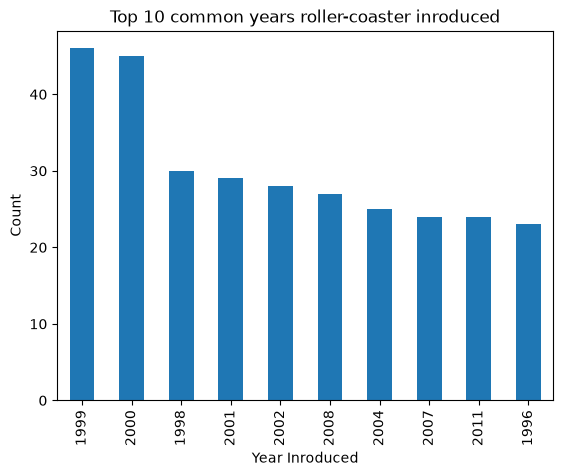

In [58]:
# traditional way to plot
'''
fig , axes = plt.subplots(1 ,1 , figsize = (10,5))

ax = sns.barplot(df['Year_Introduced'].value_counts().head(10))
ax.set_title('Top 10 common years roller-coaster inroduced')
'''
# another way (more primitive)(doesnt auto sort the x axis by year liek the one before)
ax = df['Year_Introduced'].value_counts().head(10).plot(kind='bar', title='Top 10 common years roller-coaster inroduced')

ax.set_xlabel('Year Inroduced')
ax.set_ylabel('Count')

The figure above denotes that the years 2000 and 1999 each had more than 40 new roller coaster openings.

Getting an idead for the distribution of "Speed_mph"

Text(0.5, 1.0, 'Coaster Speed dynsity -mph-')

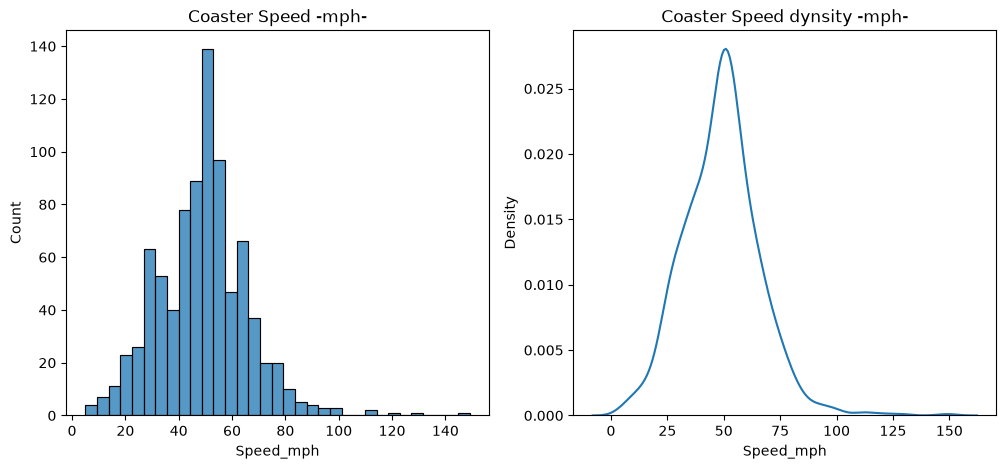

In [70]:
fig , axes = plt.subplots(1 ,2 , figsize = (12,5))

ax = sns.histplot(df['Speed_mph'], ax = axes[0])
ax.set_title('Coaster Speed -mph-')

ax1 = sns.kdeplot(df['Speed_mph'],  ax = axes[1]) # kernal dynsity plot
ax1.set_title('Coaster Speed dynsity -mph-')

Getting an idead for the distribution of "Gforce"

Text(0.5, 1.0, 'G-force dynsity')

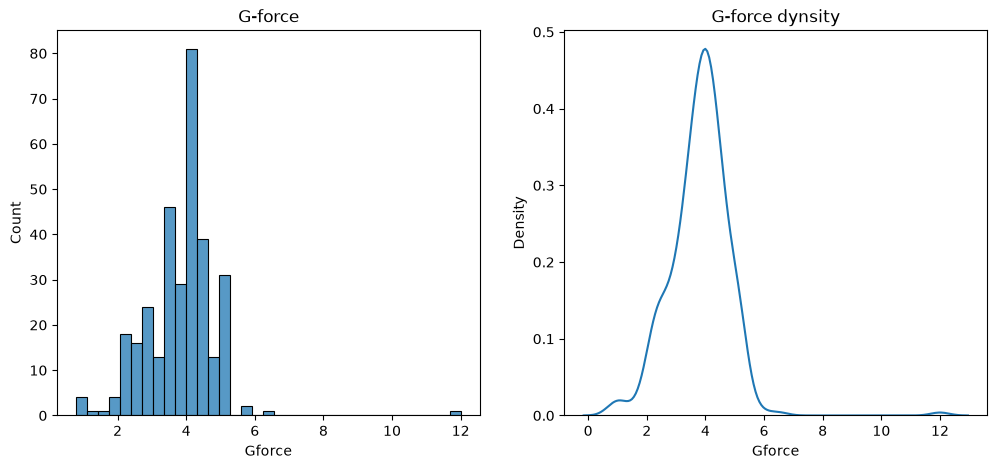

In [73]:
fig , axes = plt.subplots(1 ,2 , figsize = (12,5))

ax = sns.histplot(df['Gforce'], ax = axes[0])
ax.set_title('G-force')

ax1 = sns.kdeplot(df['Gforce'],  ax = axes[1]) # kernal dynsity plot
ax1.set_title('G-force dynsity')

Bivariate Analysis: (relation between two variables)

    pairplot.

    heatmap correlation.

    scatter plot.

    grouped box plot.

Pair Plot :

It plots every numeric variable against every other in a single grid.

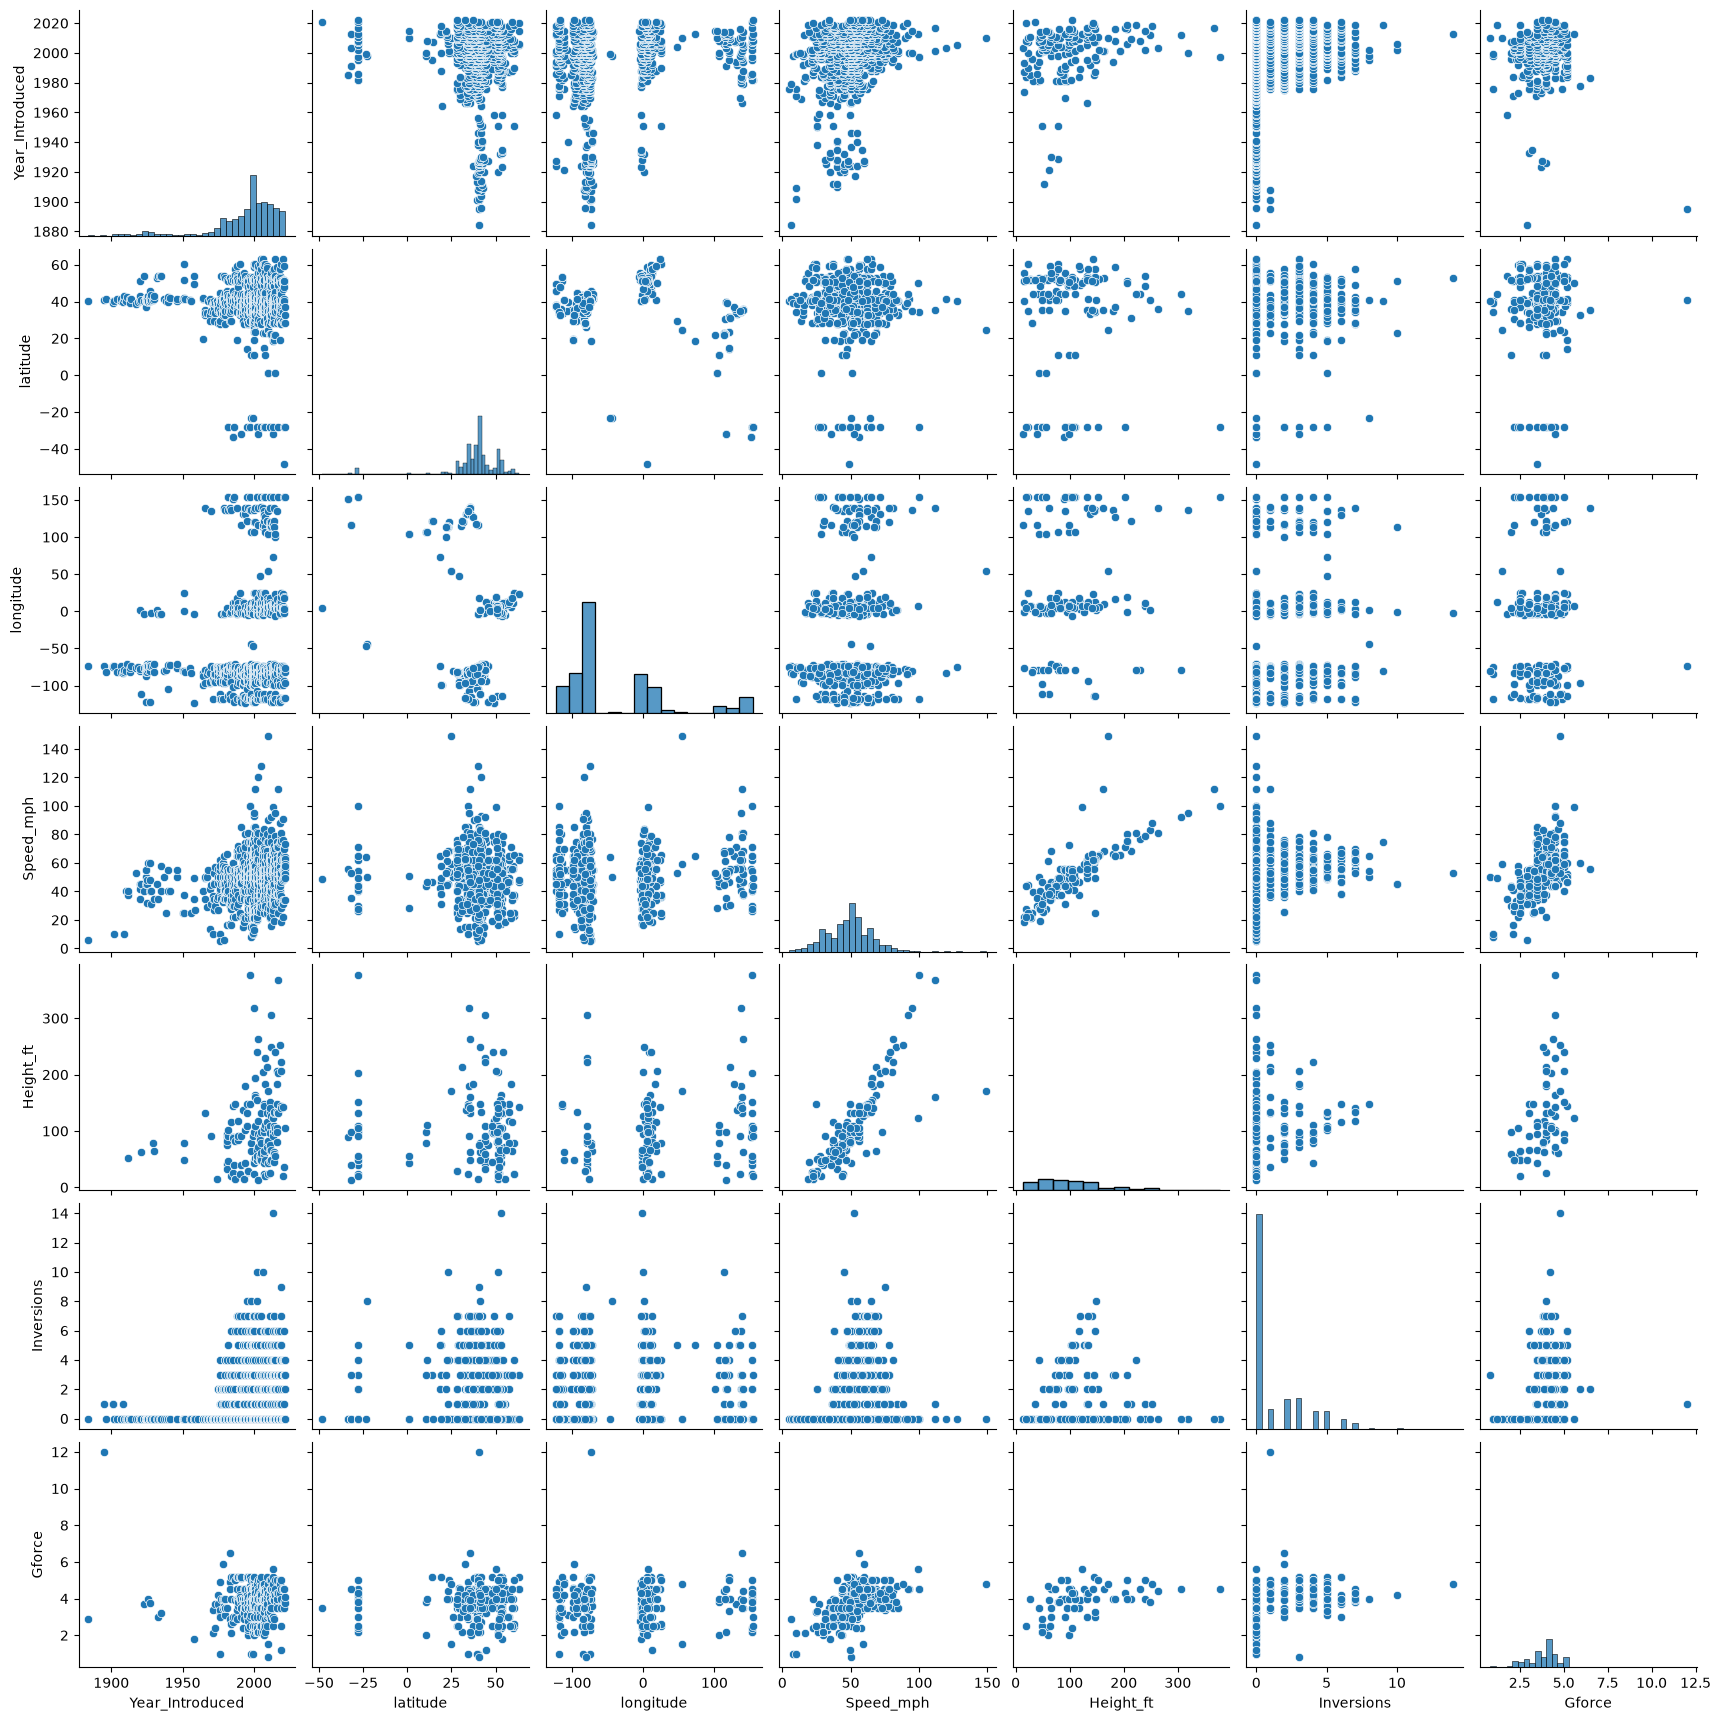

In [84]:
sns.pairplot(df) 

Correlation & Heatmap:

<Axes: >

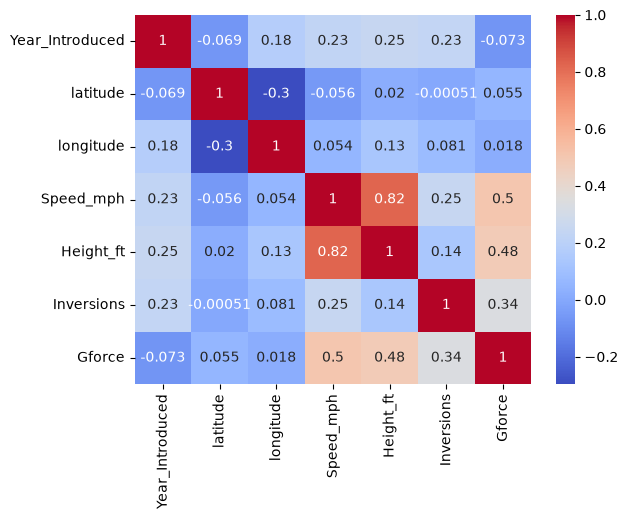

In [95]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")


On a scale from -1 to +1:

  +1 is a perfect positive relationship,

  -1 a perfect negative one

  and 0 no linear relationship.

In our figure we observe that:

  there is a strong positive correlation between (Speed_mph and Height_ft)(+0.82),

  almost no correlation between (latitude and inversions)(-0.00051)

  and a slightly negative correlation between (latitude and longitude)(-0.3).

Scatter Plot:

First, for some example positive realtions:

Text(0.5, 1.0, 'Speed-mph- vs Hight-ft-')

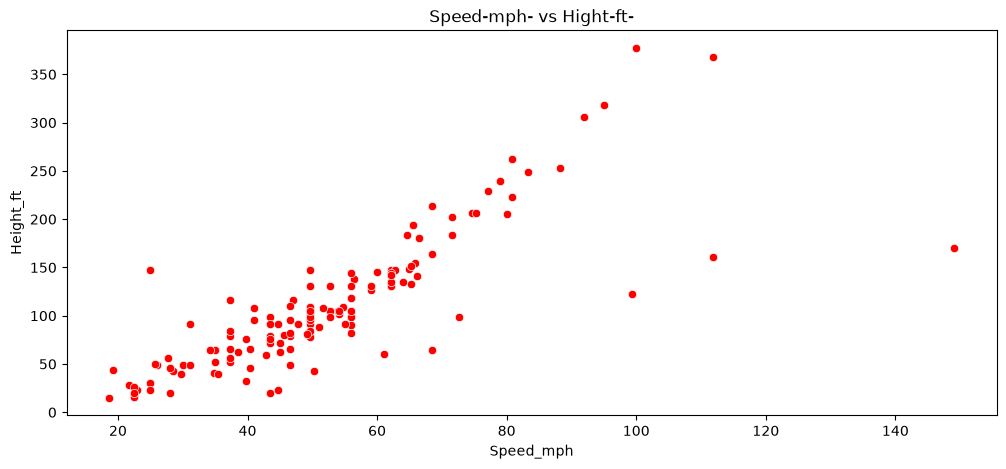

In [91]:
fig , axes = plt.subplots(1 ,1 , figsize = (12,5))

ax = sns.scatterplot(df, x ='Speed_mph', y ='Height_ft' , color = 'red')
ax.set_title('Speed-mph- vs Hight-ft-')

The figure indicated that having a faster speed is related to having a higher height.

Text(0.5, 1.0, 'Speed_mph vs Gforce')

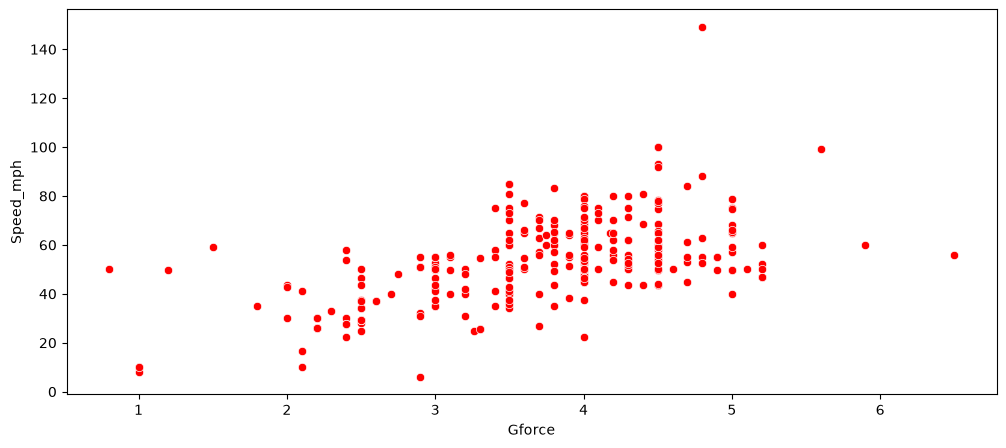

In [94]:
fig , axes = plt.subplots(1 ,1 , figsize = (12,5))

sns.scatterplot(df, y ='Speed_mph', x ='Gforce' , color = 'red')
ax.set_title('Speed_mph vs Gforce')

the figure indicates that higher Gforce can be attained with higher speeds.

In both if the above figures, we can see that the points represent an almost 45 degree line, which indicates  a positive correlation.

Box plot:

    reveals how a numeric variable differs across categories.


<Axes: xlabel='Type_Main', ylabel='Speed_mph'>

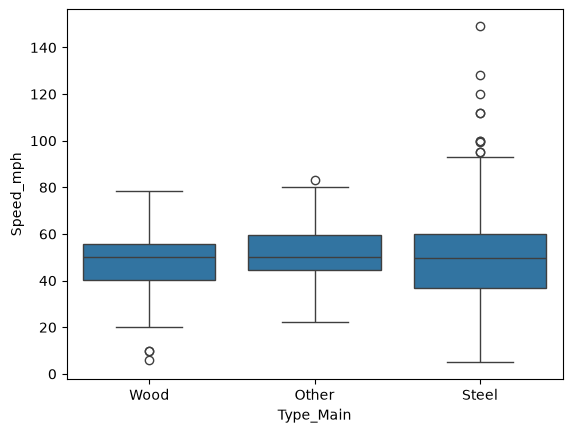

In [103]:
sns.boxplot(data=df, x="Type_Main", y="Speed_mph")

we can see from the figure the effect of materials on the obtained speed. 

we can even see the with the steel built roller coster we have a bigger variaty in speeds, along with higher max speeds (which are represented as outliers).

<Axes: xlabel='Gforce_rounded', ylabel='Height_ft'>

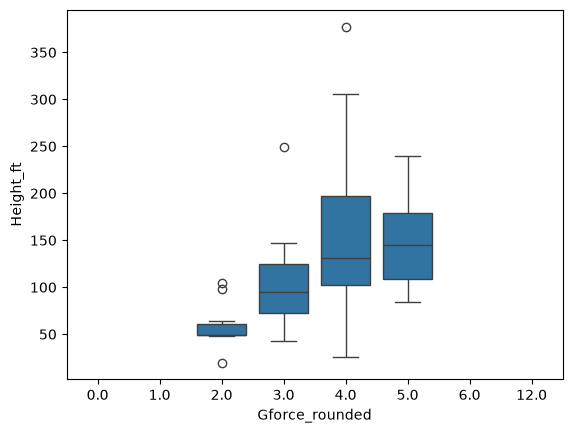

In [110]:
df['Gforce_rounded'] = np.floor(df['Gforce']) # created a new column with rounded data so that it is less sccatered and more comprehensable 
sns.boxplot(data=df, x="Gforce_rounded", y="Height_ft")

The figure above denotes a relation between hight and Gforce, and it gives us an average height range where most common G force values are attained.